In [13]:
import seaborn as sns
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation,LGBMRanker

In [14]:
import os
import pandas as pd

def load_dataset(filename):
    path = os.path.join('datasets', filename)
    return pd.read_csv(path)

training_file_raw = 'training_set_VU_DM.csv'
test_file_raw = 'test_set_VU_DM.csv'

# Example usage
df_train = load_dataset(training_file_raw)
df_test = load_dataset(test_file_raw)

In [ ]:
def engineer_features(df):
    """
    Efficient, safe, and non-leaky feature engineering.
    """
    df = df.copy()
    
    # Cap price outliers with a reasonable hard threshold (faster than winsorization)
    df['price_usd'] = np.where(df['price_usd'] > 2000, np.nan, df['price_usd'])
    df['price_per_night'] = df['price_usd'] / df['srch_length_of_stay']
    
    # Minimal, robust group-level features (AVOID repetitive heavy .groupby('srch_id').transform())
    if 'prop_starrating' in df.columns:
        df['star_rating_missing'] = df['prop_starrating'].isnull().astype(int)
    
    if 'prop_review_score' in df.columns:
        df['review_missing_flag'] = df['prop_review_score'].isnull().astype(int)
        df['prop_review_score_filled'] = df['prop_review_score'].fillna(df['prop_review_score'].median())
    
    # Rank within search (faster than percentile)
    if 'price_usd' in df.columns:
        df['price_rank_in_search'] = df.groupby('srch_id')['price_usd'].rank("min", ascending=True)
    
    # Simple competitor sum (much faster)
    comp_rate_cols = [col for col in df.columns if col.startswith('comp') and col.endswith('_rate')]
    comp_inv_cols = [col for col in df.columns if col.startswith('comp') and col.endswith('_inv')]
    if comp_rate_cols and comp_inv_cols:
        comp_sum = np.zeros(len(df))
        for rate_col, inv_col in zip(comp_rate_cols, comp_inv_cols):
            available = df[inv_col] == 0
            comp_sum += df[rate_col].where(available, 0).fillna(0).values
        df['comp_rate_sum_available'] = comp_sum

    for col in ['prop_review_score', 'prop_starrating']:  # Add only what is reasonable
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    
    return df

def compute_property_aggregates(df, prop_id_col='prop_id', exclude=None):
    """
    Compute mean, median, and count for each property using ONLY TRAIN DATA.
    """
    if exclude is None:
        exclude = [
            'srch_id', prop_id_col, 'position', 'click_bool', 'booking_bool',
            'gross_bookings_usd', 'relevance', 'price_usd', 'visitor_location_country_id',
            'prop_country_id', 'site_id', 'srch_destination_id'
        ]
    numeric = [c for c in df.select_dtypes(include='number').columns if c not in exclude]
    agg_df = df.groupby(prop_id_col)[numeric].agg(['mean', 'median', 'count'])
    agg_df.columns = [f"{col}_{stat}" for col, stat in agg_df.columns]
    agg_df = agg_df.reset_index()
    return agg_df

def finalize_features(df, prop_stats, drop_cols=None, prop_id_col='prop_id'):
    """
    Merge property stats; drop target and unneeded columns.
    """
    merged = df.merge(prop_stats, on=prop_id_col, how='left', suffixes=('', '_prop'))
    if drop_cols is None:
        drop_cols = ['position', 'click_bool', 'booking_bool', 'gross_bookings_usd',
                     'price_usd', 'date_time']
    return merged.drop(columns=[c for c in drop_cols if c in merged.columns], errors='ignore')


In [18]:
# Load datasets
train_raw = load_dataset('training_set_VU_DM.csv')
test_raw  = load_dataset('test_set_VU_DM.csv')

# Efficient feature engineering
train_feat = engineer_features(train_raw)
test_feat  = engineer_features(test_raw)

# Relevance target
train_feat['target_relevance'] = 0
train_feat.loc[train_feat['click_bool'] == 1, 'target_relevance'] = 1
train_feat.loc[train_feat['booking_bool'] == 1, 'target_relevance'] = 5

# Compute property aggregates ON TRAIN ONLY!
property_aggregates = compute_property_aggregates(train_feat)

# Merge for modeling
final_train = finalize_features(train_feat, property_aggregates)
final_test  = finalize_features(test_feat, property_aggregates)

In [19]:
# Prepare features and target
feature_cols = [col for col in final_train.columns if col not in ['srch_id', 'target_relevance']]
X_full = final_train[feature_cols]
y_full = final_train['target_relevance']

# First split: train/holdout (by srch_id groups, to avoid leakage)
group_ids_full = final_train['srch_id']
groups_full_size = group_ids_full.value_counts().sort_index().to_numpy()

gss = GroupShuffleSplit(test_size=0.2, random_state=1)
train_idx, holdout_idx = next(gss.split(X_full, y_full, groups=group_ids_full))

X_train_all = X_full.iloc[train_idx]
y_train_all = y_full.iloc[train_idx]
group_ids_train_all = group_ids_full.iloc[train_idx]

# Second split: train/validation (again group-wise)
gss_val = GroupShuffleSplit(test_size=0.2, random_state=2)
train_idx_final, val_idx = next(gss_val.split(X_train_all, y_train_all, groups=group_ids_train_all))

X_train, y_train = X_train_all.iloc[train_idx_final], y_train_all.iloc[train_idx_final]
X_val, y_val = X_train_all.iloc[val_idx], y_train_all.iloc[val_idx]

# Calculate group sizes for LightGBM Ranker
train_group_sizes = group_ids_train_all.iloc[train_idx_final].value_counts().sort_index().to_numpy()
val_group_sizes   = group_ids_train_all.iloc[val_idx].value_counts().sort_index().to_numpy()

# LightGBM Ranker model setup
ranker = LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    ndcg_eval_at=[5],
    learning_rate=0.1,
    num_leaves=64,
    min_data_in_leaf=30,
    feature_fraction=0.85,
    n_estimators=3000,
    random_state=42
)

# Model training with early stopping and evaluation logging
ranker.fit(
    X_train, y_train,
    group=train_group_sizes,
    eval_set=[(X_val, y_val)],
    eval_group=[val_group_sizes],
    callbacks=[early_stopping(stopping_rounds=30), log_evaluation(period=50)]
)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.295175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31223
[LightGBM] [Info] Number of data points in the train set: 3172170, number of used features: 202
[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] 

LGBMRanker(feature_fraction=0.85, metric='ndcg', min_data_in_leaf=30,
           n_estimators=3000, ndcg_eval_at=[5], num_leaves=64,
           objective='lambdarank', random_state=42)

In [20]:
df_test_predict = final_test.copy()

# Ensure the test set has all features the model expects (in same order)
feature_names = ranker.feature_name_
X_test_submit = df_test_predict[feature_names]

# Predict scores for ranking
pred_scores = ranker.predict(X_test_submit)
df_test_predict['predicted_score'] = pred_scores

# Prepare for submission: keep required columns and order
submission_df = (
    df_test_predict[['srch_id', 'prop_id', 'predicted_score']]
    .sort_values(by=['srch_id', 'predicted_score'], ascending=[True, False])
    .drop(columns='predicted_score')
)

# Write to CSV
submission_df.to_csv('VU-DM-2025-Group-23.csv', index=False)
print('Submission file saved as VU-DM-2025-Group-23.csv')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
Submission file saved as VU-DM-2025-Group-23.csv


                             feature  importance
0                    price_per_night         682
1               price_rank_in_search         641
2              target_relevance_mean         627
3               prop_location_score2         508
4          price_rank_in_search_mean         337
5               price_per_night_mean         299
6                srch_length_of_stay         258
7   prop_log_historical_price_median         257
8          prop_location_score2_mean         254
9        price_rank_in_search_median         234
10                       random_bool         232
11            price_per_night_median         155
12         prop_log_historical_price         140
13       prop_location_score2_median         138
14              visitor_hist_adr_usd         137
15         srch_query_affinity_score         134
16         orig_destination_distance         124
17              prop_location_score1         122
18               srch_booking_window         112
19                  

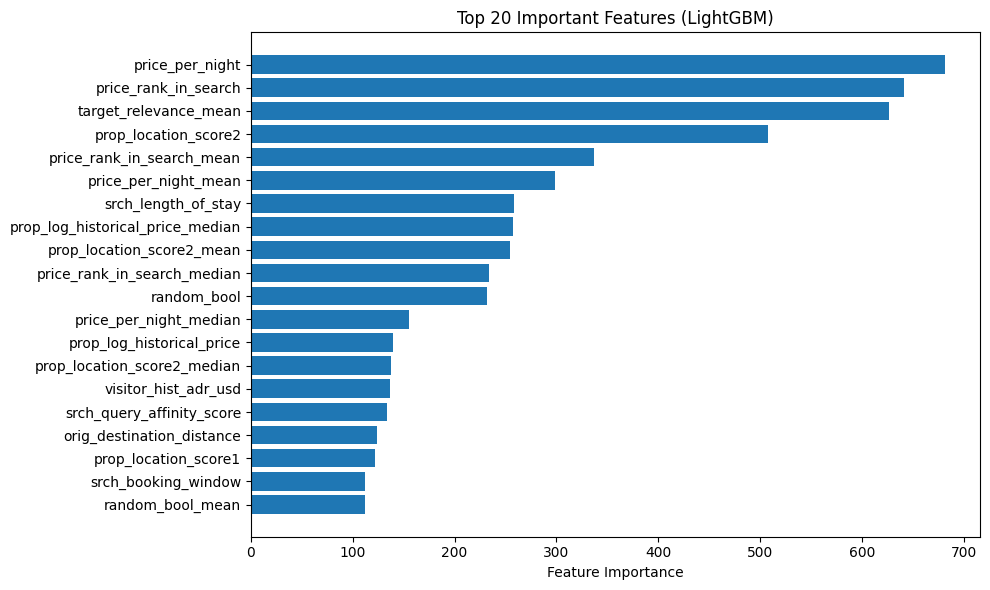

In [21]:
# Retrieve feature importances from the fitted model
feature_importances = ranker.feature_importances_
feature_names = X_train.columns

# Create DataFrame, sort by importance
feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    })
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.head(20))
print('Number of features:', len(feature_importance_df))

# Plot top 20 most important features
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Important Features (LightGBM)")
plt.tight_layout()
plt.show()

# Optionally, save full feature importances to CSV
feature_importance_df.to_csv('features_importance.csv', index=False)
